In [1]:
from PYME.IO.image import ImageStack
from PYME.IO.DataSources.CropDataSource import crop_image
from double_helix.DoubleGaussFit import Detector
import matplotlib.pyplot as plt
from scipy import ndimage
import numpy as np
import os
from PYME.recipes.processing import BackgroundSubtractionMovingPercentile
from PYME.localization.remFitBuf import fitTask
# %matplotlib widget
plt.set_loglevel("warning")
from os import path
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib import rc
from PYME.Analysis import annealThresh

In [2]:
image = ImageStack(filename = "F:/Toxoplasma_Fixed_Cell_Imaging/20250707_MyoH_ALFA_Gels/HBSS/Two_Color/Day1/FOV2_561.h5", haveGUI=False)

filename == F:\Toxoplasma_Fixed_Cell_Imaging\20250707_MyoH_ALFA_Gels\HBSS\Two_Color\Day1\FOV2_561.h5


c:\userfiles\code\python-microscopy\PYME\Analysis\MetaData.py:251: UserWarning: ADOffset fudged as 178 and probably wrong

To change ADOffset, execute the following in the console: image.mdh['Camera.ADOffset'] = newValue

Or use the Metadata pane in the GUI (right click on value to change)
  warnings.warn("ADOffset fudged as %d and probably wrong\n\nTo change ADOffset, execute the following in the console: image.mdh['Camera.ADOffset'] = newValue\n\nOr use the Metadata pane in the GUI (right click on value to change)" % md.getEntry('Camera.ADOffset'))#,'Did not find laser turn on signature')

To change ADOffset, execute the following in the console: image.mdh['Camera.ADOffset'] = newValue

Or use the Metadata pane in the GUI (right click on value to change)


F:\Toxoplasma_Fixed_Cell_Imaging\20250707_MyoH_ALFA_Gels\HBSS\Two_Color\analysis\Day1\FOV2_561.h5r


In [3]:
global_camera_crop_x_lb = 26
global_camera_crop_y_lb = 46

image_originX = image.mdh['Camera.ROIOriginX']
image_originY = image.mdh['Camera.ROIOriginY']

image_crop_col_lb = global_camera_crop_x_lb - image_originX
image_crop_row_lb = global_camera_crop_y_lb - image_originY

image_crop_size = 219

col_ub = image_crop_col_lb + image_crop_size
row_ub = image_crop_row_lb + image_crop_size

cropped_image = crop_image(image, xrange=[image_crop_col_lb, col_ub], yrange=[image_crop_row_lb, row_ub])

In [4]:
bg_sub = BackgroundSubtractionMovingPercentile().apply_simple(cropped_image)

c:\userfiles\code\python-microscopy\PYME\recipes\processing.py:2500: PYMEDeprecationWarning: This will either disappear or change function as we move to a 5D data model. Use the explicit .data_xytc instead, or even better, change to using the 5D model as image.data_xyztc or image.voxels
  bgs = BGSDataSource.DataSource(input_name.data, bgRange=self.window)
c:\userfiles\code\python-microscopy\PYME\IO\MetaDataHandler.py:672: UserWarning: DictMDHandler is not yet fully supported, and will likely cause failures for anything related to localisation fitting
  warnings.warn('DictMDHandler is not yet fully supported, and will likely cause failures for anything related to localisation fitting')


8
16


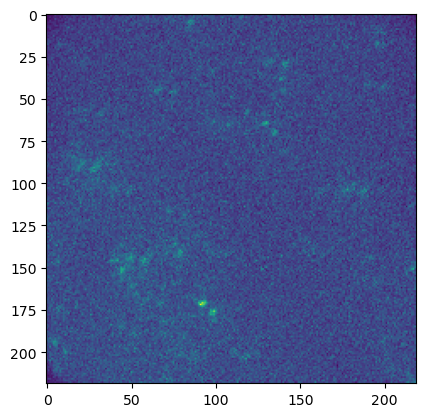

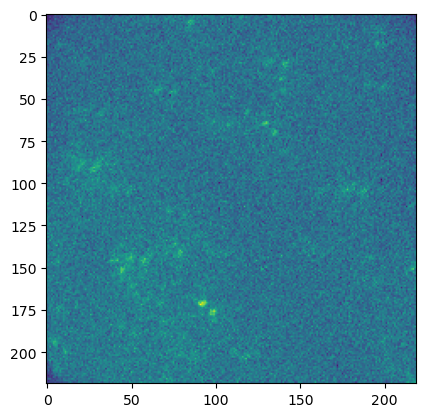

In [5]:
r = np.shape(bg_sub.data_xytc)[0]
c = np.shape(bg_sub.data_xytc)[1]

frame_num = 7062

test_frame = np.empty([r, c])
test_frame_sigma = np.empty([r, c])
test_frame_bg_subbed = np.empty([r, c])



test_frame[:,:] = np.squeeze(cropped_image.data_xytc[:,:, frame_num,:]).T
test_frame_bg_subbed[:,:] = np.squeeze(bg_sub.data_xytc[:,:, frame_num,:]).T
test_frame_sigma[:,:] = np.squeeze(fitTask.calcSigma(image.mdh, test_frame[:,:].astype('f')))


plt.figure()
plt.imshow(test_frame)

plt.figure()
plt.imshow(test_frame_sigma)


In [6]:
detector = Detector(roi_half_size=10, l_initial=900, lobe_sigma_initial=210, filter_sigma=5.0, px_size_nm=120)

Optimization terminated successfully.
         Current function value: -0.021499
         Iterations: 15
         Function evaluations: 30


In [7]:
def lobe_estimate_from_center_pixel(x_pix, y_pix, orientation, lobe_sep_px):
    dx = np.cos(orientation) * lobe_sep_px/2
    dy = np.sin(orientation) * lobe_sep_px/2
    x1 = x_pix - dx
    y1 = y_pix - dy
    x2 = x_pix + dx
    y2 = y_pix + dy
    return x1, y1, x2, y2

10.0


(-14.089205823423455, 218.5, 231.99761147965881, -0.5)

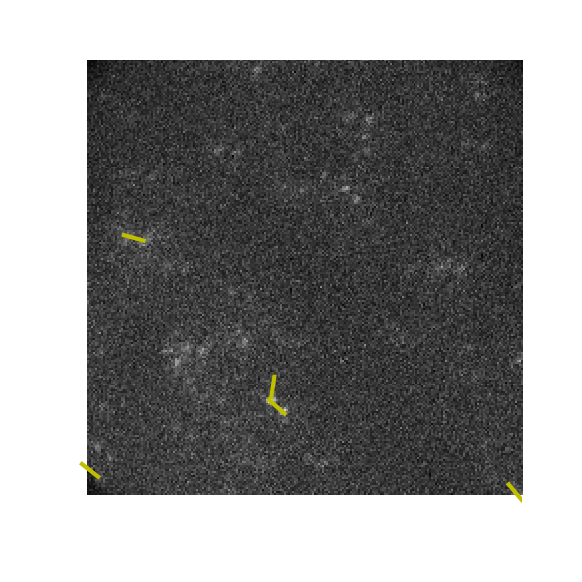

In [8]:
strength_image, angle_image = detector.filter_frame(test_frame)

thresh = 3

row, col, orientation = detector.extract_candidates(strength_image, angle_image, (thresh * test_frame_sigma)**2 * detector.normFactor)

x1, y1, x2, y2 = lobe_estimate_from_center_pixel(col, row, orientation, 1025/100)

figsize = (1, 1)  # inches
dpi = 600

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)



    

im_to_plot = test_frame
im = ax.imshow(im_to_plot, interpolation='none', cmap='gray')
ax.plot([x1, x2], [y1, y2], 'y', alpha=1, linewidth=0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.axis('off')

In [9]:
image.mdh

0.015263999812304974
0.014999999664723873
1753832481.9042284
1753829289.6320248


<NestedClassMDHandler>:

voxelsize.x: 0.12
voxelsize.y: 0.12
voxelsize.z: 0.2
voxelsize.units: um
Camera.ReadNoise: 159.2
Camera.NoiseFactor: 1.41
Camera.ElectronsPerCount: 7.08
Camera.TrueEMGain: 284.53999999999996
Camera.Binning: (1, 1)
Camera.CycleTime: 0.015263999812304974
Camera.EMGain: 300
Camera.IntegrationTime: 0.014999999664723873
Camera.Model: DU897_BV
Camera.Name: Andor IXon DV97
Camera.ROI: (3, 6, 313, 316)
Camera.ROIHeight: 310
Camera.ROIOriginX: 3
Camera.ROIOriginY: 6
Camera.ROIWidth: 310
Camera.SerialNumber: 7224
Camera.StartCCDTemp: -70
Camera.ADOffset: 178.0
tIndex: 0
ActiveCamera: EMCCD
DimOrder: XYCZT
EndTime: 1753832481.9042284 (2025-07-29 16:41:21)
SizeC: 1
SizeT: -1
SizeZ: 1
StartTime: 1753829289.6320248 (2025-07-29 15:48:09)
imageID: 0
CameraOrientation.FlipX: False
CameraOrientation.FlipY: False
CameraOrientation.Rotate: False
PYME.Version: 23.06.15.post0.dev[git]5122e91f6b78+
Positioning.x: -225.5
Positioning.x_fine: 0.0207
Positioning.x_fine_piezo: 0.0207
Posi

In [10]:
cropped_image.mdh

0.015263999812304974
0.014999999664723873
1753832481.9042284
1753829289.6320248


<NestedClassMDHandler>:

voxelsize.x: 0.12
voxelsize.y: 0.12
voxelsize.z: 0.2
voxelsize.units: um
Camera.ReadNoise: 159.2
Camera.NoiseFactor: 1.41
Camera.ElectronsPerCount: 7.08
Camera.TrueEMGain: 284.53999999999996
Camera.Binning: (1, 1)
Camera.CycleTime: 0.015263999812304974
Camera.EMGain: 300
Camera.IntegrationTime: 0.014999999664723873
Camera.Model: DU897_BV
Camera.Name: Andor IXon DV97
Camera.ROI: (3, 6, 313, 316)
Camera.ROIHeight: 310
Camera.ROIOriginX: 3
Camera.ROIOriginY: 6
Camera.ROIWidth: 310
Camera.SerialNumber: 7224
Camera.StartCCDTemp: -70
Camera.ADOffset: 178.0
tIndex: 0
ActiveCamera: EMCCD
DimOrder: XYCZT
EndTime: 1753832481.9042284 (2025-07-29 16:41:21)
SizeC: 1
SizeT: -1
SizeZ: 1
StartTime: 1753829289.6320248 (2025-07-29 15:48:09)
imageID: 0
CameraOrientation.FlipX: False
CameraOrientation.FlipY: False
CameraOrientation.Rotate: False
PYME.Version: 23.06.15.post0.dev[git]5122e91f6b78+
Positioning.x: -225.5
Positioning.x_fine: 0.0207
Positioning.x_fine_piezo: 0.0207
Posi

In [11]:
image.filename

'F:\\Toxoplasma_Fixed_Cell_Imaging\\20250707_MyoH_ALFA_Gels\\HBSS\\Two_Color\\Day1\\FOV2_561.h5'

In [12]:
cropped_image.filename = image.filename

In [13]:
cropped_image.filename

'F:\\Toxoplasma_Fixed_Cell_Imaging\\20250707_MyoH_ALFA_Gels\\HBSS\\Two_Color\\Day1\\FOV2_561.h5'

In [14]:
image.dataSource

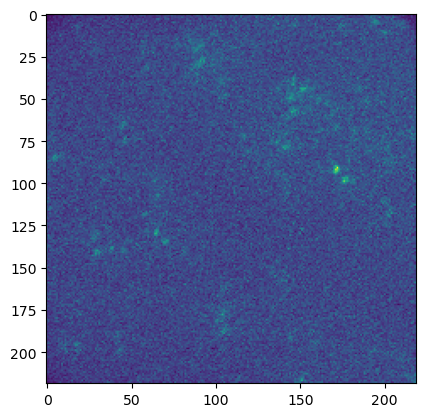

In [17]:
plt.figure()
plt.imshow(np.squeeze(cropped_image.data_xyztc[:, :, frame_num, :, :]))

In [18]:
cropped_image.save(filename="F:/Toxoplasma_Fixed_Cell_Imaging/20250707_MyoH_ALFA_Gels/HBSS/Two_Color/Day1/FOV2_561_crop.h5")

(219, 219)
